In [109]:
from tqdm import trange
import numpy as np
from scipy.stats import powerlaw, poisson, binned_statistic
from scipy.optimize import minimize
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.style.use('sans.mplstyle')

from astropy.io import fits
import astropy.units as u
import astropy.coordinates as coord
from astropy.coordinates import frame_transform_graph
from astropy.coordinates.matrix_utilities import matrix_transpose, rotation_matrix

from ezpadova import parsec

import gala.coordinates as gc
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from gala.dynamics import mockstream as ms
_ = coord.galactocentric_frame_defaults.set('v4.0')

## Ibata+21 catalog

[ADS link](https://ui.adsabs.harvard.edu/abs/2021ApJ...914..123I/abstract)

In [155]:
dtype = {
    'names':   ('star_id', 'ra', 'dec', 'plx', 'mu_ra', 'mu_dec', 'G',  'BP-RP', 'd',  'vr', 'evr', 'rvr', 'stream_id'),
    'formats': ('i8',      'f8', 'f8',  'f8',  'f8',    'f8',     'f8', 'f8',    'f8', 'f8', 'f8',  'i8' , 'i8'       )}

d = np.loadtxt('../data/apjabfcc2t1_mrt.txt', dtype=dtype, skiprows=41)

## Ibata+24 catalog

[ADS link](https://ui.adsabs.harvard.edu/abs/2024ApJ...967...89I/abstract)

In [157]:
dtype = {
    'names':   ('star_id', 'ra', 'dec', 'plx', 'mu_ra', 'mu_dec', 'G',  'BP-RP', 'vr', 'evr', 'rvr', 'stream_id'),
    'formats': ('i8',      'f8', 'f8',  'f8',  'f8',    'f8',     'f8', 'f8',    'f8', 'f8',  'i8' , 'i8'       )}

d = np.loadtxt('../data/apjad382dt1_mrt.txt', dtype=dtype, skiprows=54)

In [156]:
c = coord.ICRS(ra=d['ra'] * u.deg, dec=d['dec'] * u.deg,
    distance=d['d'] * u.kpc,
    pm_ra_cosdec=d['mu_ra'] * u.mas/u.yr,
    pm_dec=d['mu_dec'] * u.mas/u.yr,
    radial_velocity=d['vr'] * u.km/u.s)

c_gal = c.transform_to(coord.Galactic())
l = c_gal.l
b = c_gal.b

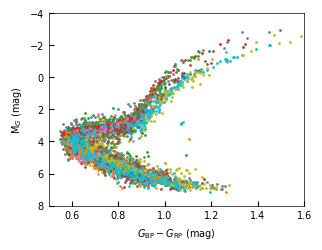

In [4]:
G_abs = d['G'] - 5*(np.log10(d['d'])+2)

for idx in set(d['stream_id']):
    mask = d['stream_id'] == idx
    plt.scatter(d['BP-RP'][mask], G_abs[mask], s=1)

plt.xlabel(r'$G_{\rm BP}-G_{\rm RP}\ ({\rm mag})$')
plt.ylabel(r'${\rm M}_{G}\ ({\rm mag})$')
plt.xlim(0.5,1.6)
plt.ylim(8,-4)
plt.show()

In [5]:
def feh_to_Z(feh):
    return 10.0**(feh)*0.0152

In [6]:
feh_list = np.array([-1.9, -1.5, -1.3, -1.1, -0.7])
Z_list = feh_to_Z(feh_list)

old_iso= [parsec.get_one_isochrone(1.25e10,Z,model='parsec12s_r14',phot='gaia') for Z in Z_list]

Interrogating http://stev.oapd.inaf.it...
Interrogating http://stev.oapd.inaf.it...
Interrogating http://stev.oapd.inaf.it...
Interrogating http://stev.oapd.inaf.it...
Interrogating http://stev.oapd.inaf.it...


In [7]:
def kroupa(mmin, mmax):
    # for 0.5 < mmax < 1 and 0.08 < mmin < 1
    if mmin == 0:
        return -0.676877 * mmax**-0.3 + 1.19048
    if mmin < 0.5:
        return -0.676877 * mmax**-0.3 - 0.580180 * mmin**0.7 + 1.19048
    else:
        return -0.676877 * (mmax**-0.3 - mmin**-0.3)

kroupa = np.vectorize(kroupa)

def power_law_imf(mmin, mmax, slope):
    pass

459.95008222712914


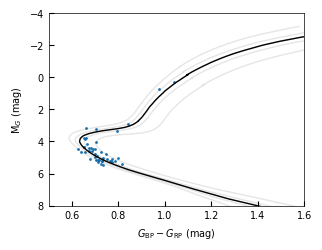

In [8]:
G_limit = 18

# gc_stream_list = ['NGC_3201', 'NGC_4590', 'NGC_5139', 'Pal_5', 'NGC_6341', 'NGC_6397']
# gc_stream_ids = np.array([9, 32, 16, 19, 24, 26], dtype=int)
# 8: GD-1
# 19: Pal 5

# for idx in set(d['stream_id']):
for idx in [6]:
    mask = (d['stream_id'] == idx) & (d['G']<=G_limit)
    plt.scatter(d['BP-RP'][mask], G_abs[mask], s=1)

# for idx in set(d['stream_id']):
#     mask = d['stream_id'] == idx
#     plt.scatter(d['BP-RP'][mask], G_abs[mask], s=1)
    
comp = np.inf
idx = np.nan

for i in range(len(old_iso)):
    iso = old_iso[i]
    mask1 = iso['label'] <= 3
    color = iso['G_BPmag'][mask1][::-1]-iso['G_RPmag'][mask1][::-1]
    Gmag = iso['Gmag'][mask1][::-1]

    dcolor = d['BP-RP'][mask] - np.interp(G_abs[mask], Gmag, color)
    dcolor = np.mean(dcolor**2)
    if dcolor < comp:
        comp = dcolor
        idx = i
    
    plt.plot(color, Gmag, lw=1, c='k', alpha=0.1)
    
iso = old_iso[idx]
mask1 = iso['label'] <= 3
color = iso['G_BPmag'][mask1][::-1]-iso['G_RPmag'][mask1][::-1]
Gmag = iso['Gmag'][mask1][::-1]
Mini = iso['Mini'][mask1][::-1]
masses = np.interp(G_abs[mask], Gmag, Mini)
plt.plot(color, Gmag, lw=1, c='k', alpha=1)

mass_limit = np.interp(G_limit - 5*(np.log10(d['d'][mask])+2), Gmag, Mini)
weight = kroupa(0, np.max(Mini)) / kroupa(mass_limit, np.max(Mini))
print(np.sum(masses*weight))

plt.xlabel(r'$G_{\rm BP}-G_{\rm RP}\ ({\rm mag})$')
plt.ylabel(r'${\rm M}_{G}\ ({\rm mag})$')
plt.xlim(0.5,1.6)
plt.ylim(8,-4)
plt.show()

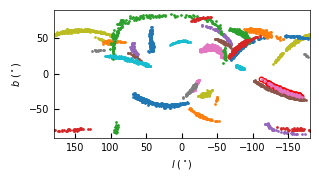

In [9]:


mask = d['stream_id'] == 6
plt.scatter(l[mask].wrap_at(180*u.deg), b[mask], s=10, fc='none', ec='r')

for idx in range(100):
    mask = d['stream_id'] == idx
    plt.scatter(l[mask].wrap_at(180*u.deg), b[mask], s=1)

plt.xlabel(r'$l\ (^\circ)$')
plt.ylabel(r'$b\ (^\circ)$')
plt.xlim(180,-180)
plt.ylim(-90,90)
plt.gca().set_aspect(1)
plt.show()

### Pal 5 from CFHT

In [10]:
# hdul = fits.open('../data/pal_5_cfht_ibata17.fit')
# data = hdul[1].data
# hdul.close()

In [11]:
# plt.hist2d(data['g0mag']-data['r0mag'], data['g0mag'], bins=(np.arange(-0.5,2.01,0.01), np.arange(16,24.1,0.1)), norm=mpl.colors.LogNorm())

# plt.ylim(24,16)
# plt.show()

## Load GCs

In [12]:
# load MW metal and mass

mass_mw = []
name_mass_mw = []
feh_mw = []
name_feh_mw = []
f_mw = '../data/combined_table_mass.txt'
with open(f_mw, 'rb') as reader:
    lines = reader.readlines()[2:160]
    for line in lines:
        mass_mw.append(np.log10(float(line[65:76])))
        name_mass_mw.append(str(line[0:13].strip())[2:-1].replace(' ', '_'))
f_mw = '../data/mwgc.dat'
with open(f_mw, 'rb') as reader:
    lines = reader.readlines()[252:409]
    for line in lines:
        fehh = str(line[13:19].strip())[2:-1]
        if len(fehh) == 0:
            continue
        feh_mw.append(float(fehh))
        name_feh_mw.append(str(line[1:13].strip())[2:-1].replace(' ', '_'))
mass_mw = np.array(mass_mw)
name_mass_mw = np.array(name_mass_mw)
feh_mw = np.array(feh_mw)
name_feh_mw = np.array(name_feh_mw)

xy, idx1, idx2 = np.intersect1d(name_feh_mw, name_mass_mw, return_indices=True)

# load mw pos and vel

dtype5 = {
    'names': (
        'Cluster', 'RA', 'DEC', 'l', 'b', 'Rsun', 'ERsun', 'R_GC', '<RV>', 'ERV',
        'mu_alpha', 'Dmu_alpha', 'mu_delta', 'Dmu_delta', 'rhopmrade', 'X', 'DX', 
        'Y', 'DY', 'Z', 'DZ', 'U', 'DU', 'V', 'DV', 'W', 'DW', 'RPERI', 'DRPERI', 'RAPO', 'DRAPO'),
    'formats': (
        'U16', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 
        'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8',
        'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8')}
path = '../data/orbits_table_v4.txt'
data_mw = np.loadtxt(path, dtype=dtype5)

x_mw = data_mw['X']
y_mw = data_mw['Y']
z_mw = data_mw['Z']
vx_mw = data_mw['U']
vy_mw = data_mw['V']
vz_mw = data_mw['W']

logr_mw = np.log10(np.sqrt(x_mw**2 + y_mw**2))
logr3d_mw = np.log10(np.sqrt(x_mw**2 + y_mw**2 + z_mw**2))
r_mw = np.sqrt(x_mw**2 + y_mw**2 + z_mw**2)
name_rho_mw = data_mw['Cluster']

l_wrap_at_180 = np.copy(data_mw['l'])
l_wrap_at_180[data_mw['l']>180] -= 360

ra_wrap_at_180 = np.copy(data_mw['RA'])
ra_wrap_at_180[data_mw['RA']>180] -= 360

# load structure

dtype0 = {
    'names': (
        'Cluster', 'RA', 'DEC', 'R_Sun', 'DR_Sun', 'R_GC', 'DR_GC', 'N_RV', 'N_PM', 'Mass', 'DM',
        'V', 'DV', 'M/L_V', 'DM/L', 'rc', 'rh,l', 'rh,m', 'rt', 'rho_c', 'rho_h,m', 'sig_c', 
        'sig_h,m', 'lg Trh', 'lg Mini',  'T_Diss', 'M_Low', 'M_High', 'MF', 'symbol', 'DMF', 
        'sig0', 'vesc', 'etac', 'etah'),
    'formats': (
        'U16', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8',
        'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8',
        'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'U4', 'f8', 
        'f8', 'f8', 'f8', 'f8')}
path = '../data/combined_table.txt'
data_structure_mw = np.loadtxt(path, dtype=dtype0)

In [13]:
# Ibata+21
gc_stream_list = ['NGC_288', 'NGC_1261', 'NGC_1851', 'NGC_2298', 'NGC_2808', 'NGC_3201', 'NGC_4590', 'NGC_5139', 'NGC_5466', 'Pal_5',
'NGC_5904', 'NGC_6101', 'NGC_6341', 'NGC_6397', 'NGC_7089']
gc_stream_list = ['NGC_3201', 'NGC_4590', 'NGC_5139', 'Pal_5', 'NGC_6341', 'NGC_6397']
gc_stream_ids = np.array([9, 32, 16, 19, 24, 26], dtype=int)
gc_stream_list = ['NGC_3201', 'NGC_4590', 'NGC_5139', 'Pal_5', 'NGC_6341', 'NGC_6397']
gc_stream_ids = np.array([6, 22, 16, 19, 24, 26], dtype=int)
# gc_stream_list = ['NGC_3201', 'NGC_4590', 'Pal_5', 'NGC_6341', 'NGC_6397'] # omega cen is too massive. exclude here.
# gc_stream_ids = np.array([6, 22, 19, 24, 26], dtype=int) # NGC_3201 can be either 6 or 9; NGC 4590 can be either 22 or 32
gc_stream_list, idx_with_stream, idx_with_stream_stream = np.intersect1d(data_mw['Cluster'], gc_stream_list, return_indices=True)
gc_stream_ids = gc_stream_ids[idx_with_stream_stream]

In [288]:
# Ibata+24

gc_stream_list = ['NGC_3201', 'NGC_4590', 'NGC_5139', 'Pal_5', 'NGC_6341', 'NGC_6397',
    'NGC_288', 'NGC_1261', 'NGC_1851', 'NGC_2298', 'NGC_2808', 'NGC_5466', 'NGC_5904', 'NGC_6101', 'NGC_7089']
gc_stream_ids = np.array([34, 47, 54, 61, 68, 69,
    3, 12, 16, 23, 26, 57, 62, 67, 76], dtype=int)
gc_stream_list = ['NGC_3201', 'NGC_4590', 'NGC_5139', 'Pal_5', 'NGC_6341', 'NGC_6397',
    'NGC_288', 'NGC_1851', 'NGC_2298', 'NGC_2808', 'NGC_5904', 'NGC_6101'] # remove 7089: too few stars; remove 1261, 5466, 7099: can't fit
gc_stream_ids = np.array([34, 47, 54, 61, 68, 69,
    3, 16, 23, 26, 62, 67], dtype=int)
gc_stream_list, idx_with_stream, idx_with_stream_stream = np.intersect1d(data_mw['Cluster'], gc_stream_list, return_indices=True)
gc_stream_ids = gc_stream_ids[idx_with_stream_stream]

In [180]:
cs = ['k', 'r', 'b', 'g', 'm', 'orange'] * 3
for i in range(len(gc_stream_ids)):
    mask = d['stream_id'] == gc_stream_ids[i]
    plt.scatter(l[mask].wrap_at(180*u.deg), b[mask], c=cs[i], s=1)
    plt.scatter(l_wrap_at_180[idx_with_stream][i],data_mw['b'][idx_with_stream][i], fc=cs[i], ec='w', lw=2, label=gc_stream_list[i])

plt.xlabel(r'$l\ (^\circ)$')
plt.ylabel(r'$b\ (^\circ)$')
plt.xlim(100,-180)
plt.ylim(-45,90)
plt.legend(loc='lower left', frameon=False)
plt.gca().set_aspect(1)
plt.show()

IndexError: boolean index did not match indexed array along dimension 0; dimension is 5960 but corresponding boolean dimension is 24540

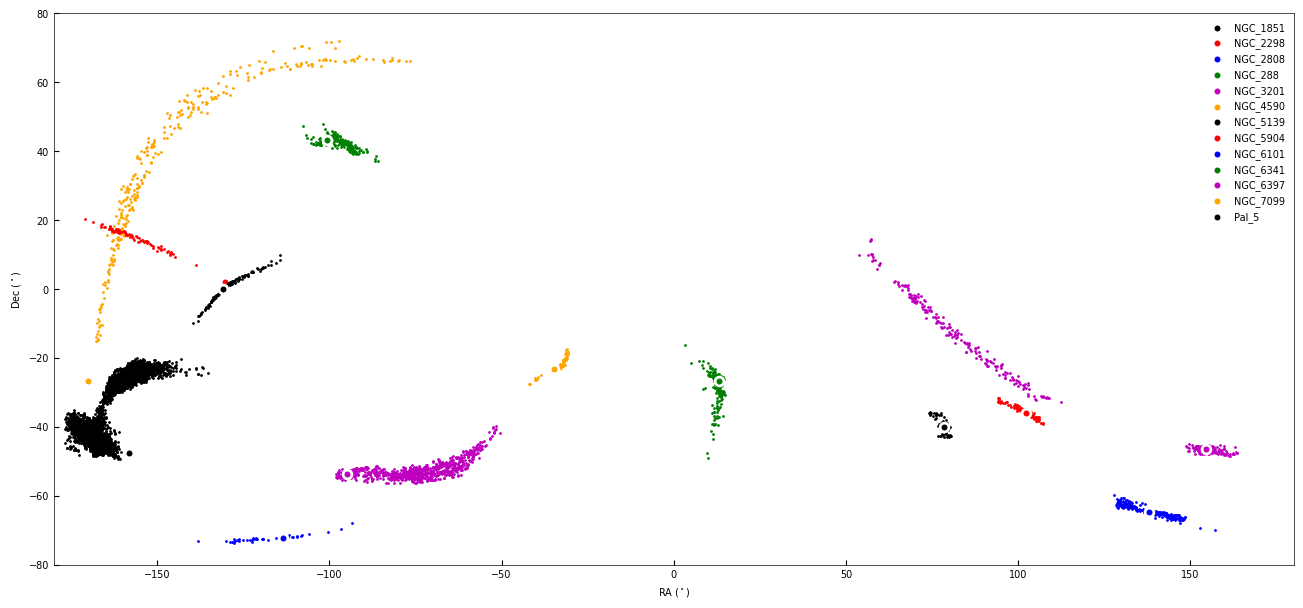

In [284]:

fig, ax0 = plt.subplots(1, 1, figsize=(16,8), sharex=False, sharey=False)

cs = ['k', 'r', 'b', 'g', 'm', 'orange'] * 3
for i in range(len(gc_stream_ids)):
    mask = d['stream_id'] == gc_stream_ids[i]
    x = np.copy(d['ra'])
    x[d['ra']>180] -= 360
    plt.scatter(x[mask], d['dec'][mask], c=cs[i], s=1)
    plt.scatter(ra_wrap_at_180[idx_with_stream][i],data_mw['DEC'][idx_with_stream][i], fc=cs[i], ec='w', lw=2, s=40, label=gc_stream_list[i])

plt.xlabel(r'RA $(^\circ)$')
plt.ylabel(r'Dec $(^\circ)$')
plt.xlim(-180,180)
plt.ylim(-80,80)
plt.legend(loc='upper right', frameon=False)
plt.gca().set_aspect(1)
plt.show()

### Fit streams with gala

In [16]:
pot = gp.BovyMWPotential2014(units=galactic)
# pot = gp.MilkyWayPotential2022(units=galactic)
H = gp.Hamiltonian(pot)

NGC_1851 GC mass = 2.81e+05 Msun, Rperi = 0.90 kpc, Rapo = 19.90 kpc
NGC_2298 GC mass = 5.72e+04 Msun, Rperi = 0.97 kpc, Rapo = 16.49 kpc
NGC_2808 GC mass = 8.69e+05 Msun, Rperi = 1.08 kpc, Rapo = 14.60 kpc
NGC_288 GC mass = 9.84e+04 Msun, Rperi = 1.93 kpc, Rapo = 12.34 kpc
NGC_3201 GC mass = 1.41e+05 Msun, Rperi = 8.34 kpc, Rapo = 25.52 kpc
NGC_4590 GC mass = 1.32e+05 Msun, Rperi = 8.88 kpc, Rapo = 29.37 kpc
NGC_5139 GC mass = 3.34e+06 Msun, Rperi = 1.47 kpc, Rapo = 6.95 kpc
NGC_5904 GC mass = 3.68e+05 Msun, Rperi = 3.25 kpc, Rapo = 23.44 kpc
NGC_6101 GC mass = 1.30e+05 Msun, Rperi = 10.19 kpc, Rapo = 35.74 kpc
NGC_6341 GC mass = 3.12e+05 Msun, Rperi = 1.25 kpc, Rapo = 10.62 kpc
NGC_6397 GC mass = 8.98e+04 Msun, Rperi = 2.60 kpc, Rapo = 6.30 kpc
NGC_7099 GC mass = 1.39e+05 Msun, Rperi = 1.51 kpc, Rapo = 8.56 kpc
Pal_5 GC mass = 1.71e+04 Msun, Rperi = 8.88 kpc, Rapo = 17.54 kpc


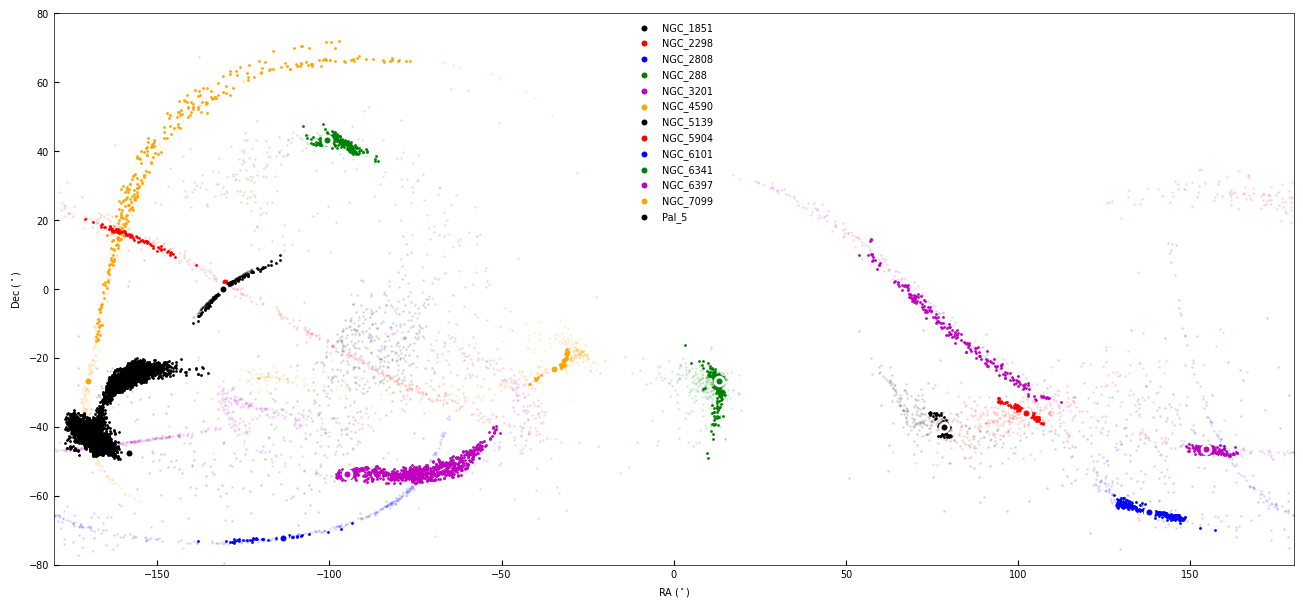

In [285]:
frame = 'ICRS'
t_tot = 2000 * u.Myr
dt = 10 * u.Myr

fig, ax0 = plt.subplots(1, 1, figsize=(16,8), sharex=False, sharey=False)

for i in range(len(gc_stream_ids)):
    mask = d['stream_id'] == gc_stream_ids[i]
    if frame == 'ICRS':
        x = np.copy(d['ra'])
        x[d['ra']>180] -= 360
        plt.scatter(x[mask], d['dec'][mask], c=cs[i], s=1)
    elif frame == 'Galactic':
        plt.scatter(l[mask].wrap_at(180*u.deg), b[mask], c=cs[i], s=1)

    c = coord.ICRS(ra=data_mw['RA'][idx_with_stream][i] * u.deg, dec=data_mw['DEC'][idx_with_stream][i] * u.deg,
        distance=data_mw['Rsun'][idx_with_stream][i] * u.kpc,
        pm_ra_cosdec=data_mw['mu_alpha'][idx_with_stream][i] * u.mas/u.yr,
        pm_dec=data_mw['mu_delta'][idx_with_stream][i] * u.mas/u.yr,
        radial_velocity=data_mw['<RV>'][idx_with_stream][i] * u.km/u.s)
    
    # c = coord.Galactocentric(
    #     x=-data_mw['X'][idx_with_stream][i] * u.kpc, 
    #     y=-data_mw['Y'][idx_with_stream][i] * u.kpc,
    #     z=data_mw['X'][idx_with_stream][i] * u.kpc,
    #     v_x=-data_mw['U'][idx_with_stream][i] * u.km/u.s,
    #     v_y=-data_mw['V'][idx_with_stream][i] * u.km/u.s,
    #     v_z=data_mw['W'][idx_with_stream][i] * u.km/u.s)
    
    c_gc = c.transform_to(coord.Galactocentric()).cartesian
    gc_w0 = gd.PhaseSpacePosition(c_gc)
    gc_mass = 10**mass_mw[np.where(name_mass_mw == gc_stream_list[i])[0][0]] * u.Msun
    print('%s GC mass = %.2e Msun, Rperi = %.2f kpc, Rapo = %.2f kpc'%(
        gc_stream_list[i], gc_mass.value, data_mw['RPERI'][idx_with_stream][i], data_mw['RAPO'][idx_with_stream][i]))
    gc_pot = gp.PlummerPotential(m=gc_mass, b=4*u.pc, units=galactic)

    df = ms.ChenStreamDF()
    gen = ms.MockStreamGenerator(df, pot, progenitor_potential=gc_pot)
    stream, _ = gen.run(gc_w0, gc_mass, dt=-dt, n_steps=int(t_tot/dt))
    
    if frame == 'ICRS':
        stream_c = stream.to_coord_frame(coord.ICRS())
        plt.scatter(stream_c.ra.wrap_at(180*u.deg), stream_c.dec, s=1, alpha=0.1, fc=cs[i])
        plt.scatter(ra_wrap_at_180[idx_with_stream][i],data_mw['DEC'][idx_with_stream][i], fc=cs[i], ec='w', lw=2, s=40, label=gc_stream_list[i])
    elif frame == 'Galactic':
        stream_c = stream.to_coord_frame(coord.Galactic())
        plt.scatter(stream_c.l.wrap_at(180*u.deg), stream_c.b, s=1, alpha=0.1, fc=cs[i])
        plt.scatter(l_wrap_at_180[idx_with_stream][i],data_mw['b'][idx_with_stream][i], fc=cs[i], ec='w', lw=2, s=40, label=gc_stream_list[i])
    
if frame == 'ICRS':
    plt.xlabel(r'RA $(^\circ)$')
    plt.ylabel(r'Dec $(^\circ)$')
    plt.xlim(-180,180)
    plt.ylim(-80,80)
elif frame == 'Galactic':
    plt.xlabel(r'$l\ (^\circ)$')
    plt.ylabel(r'$b\ (^\circ)$')
    plt.xlim(100,-180)
    plt.ylim(-45,90)

plt.legend(frameon=False)
plt.gca().set_aspect(1)
plt.show()

### construct great circle system

In [258]:
def rotate1(angles, ra, dec):
    alpha = angles[0]
    beta = angles[1]
    mat = rotation_matrix(beta*u.deg, 'x') @ rotation_matrix(alpha*u.deg, 'z')
    x = np.cos(dec) * np.cos(ra)
    y = np.cos(dec) * np.sin(ra)
    z = np.sin(dec)

    pos = np.row_stack((x,y,z))
    pos_new = mat @ pos
    x = pos_new[0]
    y = pos_new[1]
    z = pos_new[2]

    phi1 = np.arctan2(y, x)
    phi2 = np.arcsin(z)

    return np.mean(phi2**2)

def rotate2(angles, alpha, beta, ra, dec):
    gamma = angles[0]
    mat = rotation_matrix(gamma*u.deg, 'z') @ rotation_matrix(beta*u.deg, 'x') @ rotation_matrix(alpha*u.deg, 'z')
    x = np.cos(dec) * np.cos(ra)
    y = np.cos(dec) * np.sin(ra)
    z = np.sin(dec)

    pos = np.row_stack((x,y,z))
    pos_new = mat @ pos
    x = pos_new[0]
    y = pos_new[1]
    z = pos_new[2]

    phi1 = np.arctan2(y, x)
    phi2 = np.arcsin(z)

    return np.mean(phi1**2)

G_limit = 19

alpha_stream_list = np.full(len(gc_stream_ids), fill_value=np.nan)
beta_stream_list = np.full(len(gc_stream_ids), fill_value=np.nan)
gamma_stream_list = np.full(len(gc_stream_ids), fill_value=np.nan)
mat_stream_list = np.full((len(gc_stream_ids),3,3), fill_value=np.nan)

for i in range(len(gc_stream_ids)):
    mask = (d['stream_id'] == gc_stream_ids[i]) & (d['G']<=G_limit)
    # stream_obs_c = coord.ICRS(ra=d['ra'][mask]*u.deg, dec=d['dec'][mask]*u.deg)

    ra = d['ra'][mask]*np.pi/180 # in rad
    dec = d['dec'][mask]*np.pi/180 # in rad

    record = np.inf
    for guess1 in range(-180,181,30):
        for guess2 in range(-180,181,30):
            o = minimize(rotate1, (guess1,guess2), args=(ra, dec))
            if o.fun < record:
                alpha = o.x[0]
                beta = o.x[1]
                record = o.fun
    # print(np.sqrt(record)*180/np.pi)
    o = minimize(rotate2, (0), args=(alpha, beta, ra, dec))
    # print(np.sqrt(o.fun)*180/np.pi)
    gamma = o.x[0]
    # print(alpha, beta, gamma)
    mat = rotation_matrix(gamma*u.deg, 'z') @ rotation_matrix(beta*u.deg, 'x') @ rotation_matrix(alpha*u.deg, 'z')

    alpha_stream_list[i] = alpha
    beta_stream_list[i] = beta
    gamma_stream_list[i] = gamma
    mat_stream_list[i] = mat

In [259]:
# IC for progenitor

c_list = []
for i in range(len(gc_stream_ids)):
    if gc_stream_list[i] == 'Pal_5':
        # use Koposov+17 values
        c = coord.ICRS(
            ra=229 * u.deg, 
            dec=-0.111 * u.deg,
            distance=23.6 * u.kpc,
            pm_ra_cosdec=-2.23 * u.mas/u.yr,
            pm_dec=-2.22 * u.mas/u.yr,
            radial_velocity=-57.4 * u.km/u.s)
    else:
        # use GC catalog values
        c = coord.ICRS(
            ra=data_mw['RA'][idx_with_stream][i] * u.deg, 
            dec=data_mw['DEC'][idx_with_stream][i] * u.deg,
            distance=data_mw['Rsun'][idx_with_stream][i] * u.kpc,
            pm_ra_cosdec=data_mw['mu_alpha'][idx_with_stream][i] * u.mas/u.yr,
            pm_dec=data_mw['mu_delta'][idx_with_stream][i] * u.mas/u.yr,
            radial_velocity=data_mw['<RV>'][idx_with_stream][i] * u.km/u.s)
        
    c_list.append(c)

In [20]:
from scipy.signal import find_peaks

def get_peri_apo(x,y,z):
    r2 = x**2 + y**2 + z**2
    median = np.median(r2)
    peaks_apo, _ = find_peaks(r2, height=median)
    peaks_peri, _ = find_peaks(-r2, height=-median)

    return peaks_apo, peaks_peri

In [290]:
def display_name_convert(name):
    return (name
        .replace('_', ' ')
        .replace('NGC 4590', 'M68')
        .replace('NGC 5139', r'$\omega$Cen')
        .replace('NGC 6341', 'M92')
        .replace('NGC 5904', 'M5')
        )
    
def display_name_simple_convert(name):
    return (name
        .replace('_', ' ')
        .replace('NGC 4590', 'M68')
        .replace('NGC 5139', r'$\omega$Cen')
        .replace('NGC 6341', 'M92')
        .replace('NGC 5904', 'M5')
        .replace('NGC ', 'N')
        )

In [211]:
def f84(x):
    return np.percentile(x, 84)
def f16(x):
    return np.percentile(x, 16)

NGC_1851 NGC 1851 GC mass = 2.81e+05 Msun, Rperi = 0.90 kpc, Rapo = 19.90 kpc
integrated orbit: Rperi = 0.58 kpc, Rapo = 21.09 kpc
width in pc = 131.47837653435792
mass loss rates = [6.46543293 7.7227296 ]
mass loss rate = 7.108 Msun/Myr
mass loss rate / mass = 2.529e-05 1/Myr
rh / rt = 0.026

NGC_2298 NGC 2298 GC mass = 5.72e+04 Msun, Rperi = 0.97 kpc, Rapo = 16.49 kpc
integrated orbit: Rperi = 1.03 kpc, Rapo = 16.93 kpc
width in pc = 61.881585744635856
mass loss rates = [18.72276107 10.24560878]
mass loss rate = 13.078 Msun/Myr
mass loss rate / mass = 2.286e-04 1/Myr
rh / rt = 0.044

NGC_2808 NGC 2808 GC mass = 8.69e+05 Msun, Rperi = 1.08 kpc, Rapo = 14.60 kpc
integrated orbit: Rperi = 0.68 kpc, Rapo = 15.43 kpc
width in pc = 99.71520456261423
mass loss rates = [29.18340762 42.99764833]
mass loss rate = 35.461 Msun/Myr
mass loss rate / mass = 4.081e-05 1/Myr
rh / rt = 0.023

NGC_288 NGC 288 GC mass = 9.84e+04 Msun, Rperi = 1.93 kpc, Rapo = 12.34 kpc
integrated orbit: Rperi = 2.14 kpc

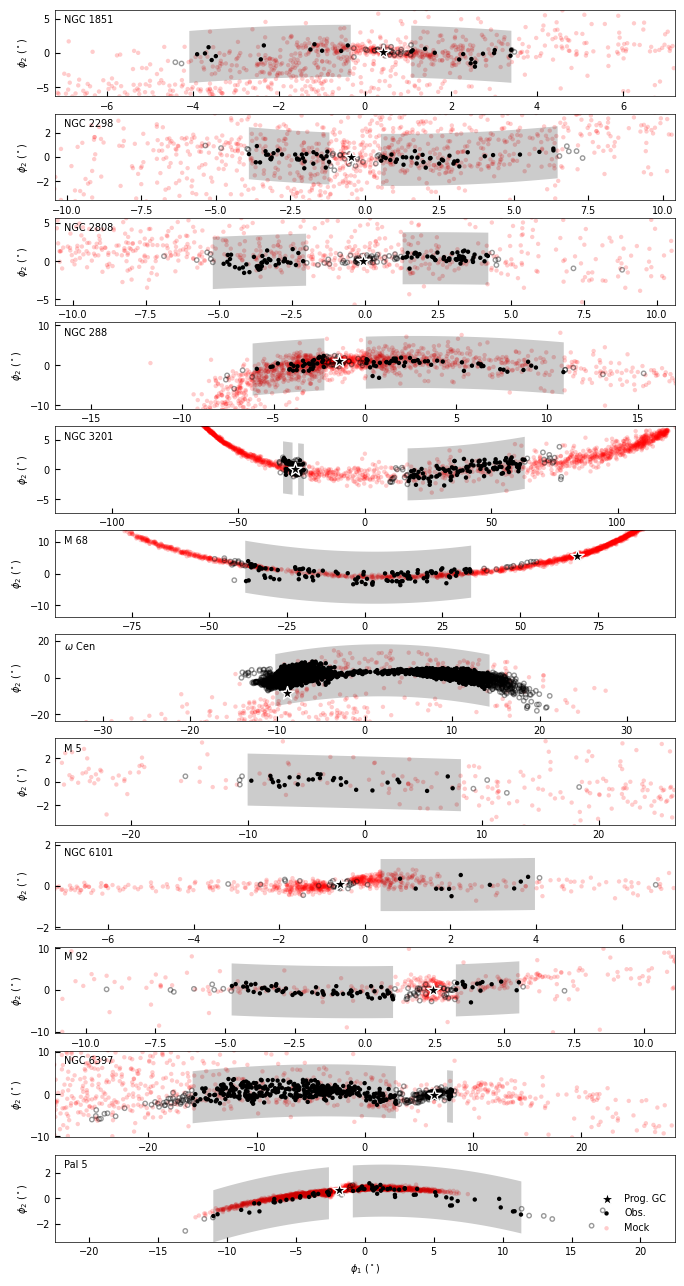

In [276]:
G_limit = 19
t_tot = 2000 * u.Myr
dt = 1 * u.Myr
n_steps = int(t_tot/dt)

center_on_poly = False

Tfrac = 0.05
N = 1000

f_rtid = 1
f_width = 6

n_obs_list = []
rate_list = []
mgc_list = []
ratio_list = []
T_list = []

# for age plot
length_list = []
width_list = []
ranges_list = []
x_age_list = []
y16_age_list = []
y84_age_list = []

class GreatCircle(coord.BaseCoordinateFrame):
    default_representation = coord.SphericalRepresentation
    default_differential = coord.SphericalCosLatDifferential

    frame_specific_representation_info = {
        coord.SphericalRepresentation: [
            coord.RepresentationMapping('lon', 'phi1'),
            coord.RepresentationMapping('lat', 'phi2'),
            coord.RepresentationMapping('distance', 'distance'),
        ]
    }

fig, axs = plt.subplots(len(gc_stream_ids), 1, figsize=(8,16), sharex=False, sharey=False)

for i in range(len(gc_stream_ids)):
    ax = axs[i]
    c = c_list[i]
    
    ax.text(0.015, 0.94, display_name_convert(gc_stream_list[i]), 
        va='top', ha='left', transform=ax.transAxes)
    
    c_gc = c.transform_to(coord.Galactocentric()).cartesian
    gc_w0 = gd.PhaseSpacePosition(c_gc)
    gc_mass = 10**mass_mw[np.where(name_mass_mw == gc_stream_list[i])[0][0]] * u.Msun
    print('%s %s GC mass = %.2e Msun, Rperi = %.2f kpc, Rapo = %.2f kpc'%(
        gc_stream_list[i], display_name_convert(gc_stream_list[i]), 
        gc_mass.value, data_mw['RPERI'][idx_with_stream][i], data_mw['RAPO'][idx_with_stream][i]))
    gc_pot = gp.PlummerPotential(m=gc_mass, b=4*u.pc, units=galactic)

    df = ms.ChenStreamDF(random_state=np.random.RandomState(0))
    gen = ms.MockStreamGenerator(df, pot, progenitor_potential=gc_pot)
    # stream, _ = gen.run(gc_w0, gc_mass, dt=-dt, n_steps=n_steps)
    
    orbit = pot.integrate_orbit(gc_w0, dt=-dt, n_steps=n_steps)
    
    pos = orbit.pos.xyz.value.T
    vel = orbit.vel.d_xyz.to('km/s').value.T

    r = np.sqrt(pos[:,0]**2 + pos[:,1]**2 + pos[:,2]**2)
    print('integrated orbit: Rperi = %.2f kpc, Rapo = %.2f kpc'%(np.min(r), np.max(r)))
    
    apos, peris = get_peri_apo(pos[:,0], pos[:,1], pos[:,2])
    T = np.mean(peris[1:] - peris[:-1])
    T_list.append(T*dt.value)
    Tsig = Tfrac * T
    rate = np.zeros(n_steps+1)
    for peri in peris:
        t_to_peri2 = (np.arange(n_steps+1) - peri)**2
        rate += 0.398942/Tsig*np.exp(-0.5*t_to_peri2/Tsig**2)/len(peris)
    
    rate = np.round(rate*N/np.sum(rate)).astype(int)
    
    stream, _ = gen.run(gc_w0, gc_mass, dt=-dt, n_steps=n_steps, n_particles=rate[::-1])
    stream_c = stream.to_coord_frame(coord.ICRS())

    @frame_transform_graph.transform(coord.StaticMatrixTransform, coord.ICRS, GreatCircle)
    def icrs_to_GreatCircle():
        return mat_stream_list[i]
    
    @frame_transform_graph.transform(coord.StaticMatrixTransform, GreatCircle, coord.ICRS)
    def GreatCircle_to_icrs():
        return matrix_transpose(mat_stream_list[i])
    
    stream_GreatCircle = stream_c.transform_to(GreatCircle())
    c_GreatCircle = c.transform_to(GreatCircle())

    # plot the progenitor GC
    phi1_gc = c_GreatCircle.phi1.wrap_at(180*u.deg).value
    phi2_gc  = c_GreatCircle.phi2.value
    if center_on_poly:
        ax.scatter(phi1_gc, phi2_gc-fit_poly(phi1_gc), s=100, marker='*', fc='k', ec='w', lw=1, zorder=100, label='Prog. GC')
    else:
        ax.scatter(phi1_gc, phi2_gc, s=100, marker='*', fc='k', ec='w', lw=1, zorder=100, label='Prog. GC')

    idx_structure = np.where(data_structure_mw['Cluster'] == gc_stream_list[i])[0]
    assert len(idx_structure) == 1
    rtid = data_structure_mw['rt'][idx_structure[0]]
    angle_rtid = (rtid / c_GreatCircle.distance.to('pc').value)*180/np.pi
        
    mask = (d['stream_id'] == gc_stream_ids[i]) & (d['G']<=G_limit)
    stream_obs_c = coord.ICRS(ra=d['ra'][mask]*u.deg, dec=d['dec'][mask]*u.deg)
    stream_obs_GreatCircle = stream_obs_c.transform_to(GreatCircle())

    phi1_obs = stream_obs_GreatCircle.phi1.wrap_at(180*u.deg).value
    phi2_obs = stream_obs_GreatCircle.phi2.value

    p = np.polyfit(phi1_obs, phi2_obs, deg=2)
    x = np.arange(-100,100,1)
    fit_poly = np.poly1d(p)
    width = np.sqrt(np.mean((phi2_obs-fit_poly(phi1_obs))**2))
    
    mask_left = (phi1_obs<phi1_gc-f_rtid*angle_rtid) & (phi2_obs-fit_poly(phi1_obs)>-f_width*width) & (phi2_obs-fit_poly(phi1_obs)<f_width*width)
    mask_right = (phi1_obs>phi1_gc+f_rtid*angle_rtid) & (phi2_obs-fit_poly(phi1_obs)>-f_width*width) & (phi2_obs-fit_poly(phi1_obs)<f_width*width)
    mask_lr = np.zeros_like(mask_left, dtype=bool)

    ranges = []
    masks = []
    if len(phi1_obs[mask_left]) >= 10:
        r = np.percentile(phi1_obs[mask_left], [10,90])
        ranges.append(r)
        mask_lr |= (mask_left & (phi1_obs>r[0]) & (phi1_obs<r[1]))
        masks.append((mask_left & (phi1_obs>r[0]) & (phi1_obs<r[1])))
    if len(phi1_obs[mask_right]) >= 10:
        r = np.percentile(phi1_obs[mask_right], [10,90])
        ranges.append(r)
        mask_lr |= (mask_right & (phi1_obs>r[0]) & (phi1_obs<r[1]))
        masks.append((mask_right & (phi1_obs>r[0]) & (phi1_obs<r[1])))
    # special treatment with omega cen, its GC is off center
    if gc_stream_list[i] == 'NGC_5139':
        r = np.percentile(phi1_obs, [10,90])
        ranges = [r]
        mask_lr = (phi2_obs-fit_poly(phi1_obs)>-f_width*width) & (phi2_obs-fit_poly(phi1_obs)<f_width*width) &  (phi1_obs>r[0]) & (phi1_obs<r[1])
        masks = [mask_lr]
    # special treatment with 3201, it has 3 segments
    if gc_stream_list[i] == 'NGC_3201':
        r = np.percentile(phi1_obs[mask_left], [10,90])
        ranges = [r]
        mask_right1 = mask_right & (phi1_obs<0)
        r = np.percentile(phi1_obs[mask_right1], [10,90])
        ranges.append(r)
        mask_right2 = mask_right & (phi1_obs>0)
        r = np.percentile(phi1_obs[mask_right2], [10,90])
        ranges.append(r)
        masks = [(mask_left & (phi1_obs>ranges[0][0]) & (phi1_obs<ranges[0][1])), 
            (mask_right1 & (phi1_obs>ranges[1][0]) & (phi1_obs<ranges[1][1])),
            (mask_right2 & (phi1_obs>ranges[2][0]) & (phi1_obs<ranges[2][1]))]
        mask_lr = ((mask_left & (phi1_obs>ranges[0][0]) & (phi1_obs<ranges[0][1])) | 
            (mask_right1 & (phi1_obs>ranges[1][0]) & (phi1_obs<ranges[1][1])) |
            (mask_right2 & (phi1_obs>ranges[2][0]) & (phi1_obs<ranges[2][1])))

    # if not center_on_poly:
    #     ax.plot(x, fit_poly(x), c='k', lw=2, alpha=0.6)

    # plot the obs. stars
    length = np.sqrt(np.mean(phi1_obs**2))
    if center_on_poly:
        ax.scatter(phi1_obs[~mask_lr], phi2_obs[~mask_lr]-fit_poly(phi1_obs[~mask_lr]), s=10, alpha=0.4, ec='k', fc='none', lw=1)
        ax.scatter(phi1_obs[mask_lr], phi2_obs[mask_lr]-fit_poly(phi1_obs[mask_lr]), s=10, alpha=1, ec='none', fc='k', label='Obs.')
        # ax.fill_between([-2*length, 2*length], [f_width*width, f_width*width], [-f_width*width, -f_width*width], ec='none', fc='k', alpha=0.2)
        for range in ranges:
            ax.fill_between(range, [f_width*width, f_width*width], [-f_width*width, -f_width*width], ec='none', fc='k', alpha=0.2)
    else:
        ax.scatter(phi1_obs[~mask_lr], phi2_obs[~mask_lr], s=10, alpha=0.4, ec='k', fc='none', lw=1)
        ax.scatter(phi1_obs[mask_lr], phi2_obs[mask_lr], s=10, alpha=1, ec='none', fc='k', label='Obs.')
        x = np.linspace(-2*length, 2*length,100)
        # ax.fill_between(x, fit_poly(x)+f_width*width, fit_poly(x)-f_width*width, ec='none', fc='k', alpha=0.2)
        for r in ranges:
            x = np.linspace(r[0], r[1],100)
            ax.fill_between(x, fit_poly(x)+f_width*width, fit_poly(x)-f_width*width, ec='none', fc='k', alpha=0.2)

    phi1_spray = stream_GreatCircle.phi1.wrap_at(180*u.deg).value
    phi2_spray = stream_GreatCircle.phi2.value
    # plot the mock stars
    if center_on_poly:
        ax.scatter(phi1_spray, phi2_spray-fit_poly(phi1_spray), s=10, alpha=0.2, fc='r', ec='none', label='Mock', zorder=0)
    else:
        ax.scatter(phi1_spray, phi2_spray, s=10, alpha=0.2, fc='r', ec='none', label='Mock', zorder=0)
    
    # compute the density for simulated streams
    num_in_range = 0
    length_in_range = 0
    density_spray_ranges = []
    for r in ranges:
        d_phi2 = phi2_spray-fit_poly(phi1_spray)
        width_spray = np.sqrt(np.mean((phi2_spray-fit_poly(phi1_spray))**2))
        weight = np.exp(-0.5*(d_phi2/width)**2) / np.exp(-0.5*(d_phi2/width_spray)**2)
        mask_in_range = (
            (phi1_spray>r[0]) & 
            (phi1_spray<=r[1]) & 
            (d_phi2>-f_width*width) & 
            (d_phi2<f_width*width)
        )
        # num_in_range += len(phi1_spray[mask_in_range])
        num_in_range += np.sum(weight[mask_in_range])
        length_in_range += r[1] - r[0]
        density_spray_ranges.append(np.sum(weight[mask_in_range])/(r[1]-r[0]))
    density_spray_ranges = np.array(density_spray_ranges)
    density_spray = num_in_range / length_in_range

    # directly get Gabs from Ibata distance
    # dist = d['d'][mask]
    # G_abs_here = G_abs[mask]
    
    # interp Gabs from fitted track. Needed for Ibata+24
    dist = np.full_like(d['G'][mask], fill_value=data_mw['Rsun'][idx_with_stream][i])
    G_abs_here = d['G'][mask] - 5*(np.log10(dist)+2)
    print('width in pc =', 1e3*data_mw['Rsun'][idx_with_stream][i]*width*np.pi/180)

    # compute the density of obs stream between phi1_l and phi1_h
    comp = np.inf
    idx = np.nan
    for j in range(len(old_iso)):
        iso = old_iso[j]
        mask1 = iso['label'] <= 3
        color = iso['G_BPmag'][mask1][::-1]-iso['G_RPmag'][mask1][::-1]
        Gmag = iso['Gmag'][mask1][::-1]
    
        dcolor = d['BP-RP'][mask] - np.interp(G_abs_here, Gmag, color)
        dcolor = np.mean(dcolor**2)
        if dcolor < comp:
            comp = dcolor
            idx = j
    iso = old_iso[idx]
    mask1 = iso['label'] <= 3
    color = iso['G_BPmag'][mask1][::-1]-iso['G_RPmag'][mask1][::-1]
    Gmag = iso['Gmag'][mask1][::-1]
    Mini = iso['Mini'][mask1][::-1]
    masses = np.interp(G_abs_here, Gmag, Mini)

    mass_limit = np.interp(G_limit - 5*(np.log10(dist)+2), Gmag, Mini)
    weight = kroupa(0, np.max(Mini)) / kroupa(mass_limit, np.max(Mini))

    mass_obs = np.sum(masses[mask_lr] * weight[mask_lr])
    density_obs_ranges = []
    for mask_seg, r in zip(masks,ranges):
        density_obs_ranges.append(np.sum(masses[mask_seg] * weight[mask_seg])/(r[1]-r[0]))
    density_obs = mass_obs / length_in_range
    density_obs_ranges = np.array(density_obs_ranges)
    n_obs_list.append(len(masses[mask_lr]))

    print('mass loss rates =', density_obs_ranges/density_spray_ranges*N/t_tot.value)
    print('mass loss rate = %.3f Msun/Myr'%(density_obs/density_spray*N/t_tot.value))
    print('mass loss rate / mass = %.3e 1/Myr'%(density_obs/density_spray*N/t_tot.value/gc_mass.value))
    rate_list.append(density_obs/density_spray*N/t_tot.value)
    mgc_list.append(gc_mass.value)

    idx_structure = np.where(data_structure_mw['Cluster'] == gc_stream_list[i])[0]
    assert len(idx_structure) == 1
    ratio = data_structure_mw['rh,m'][idx_structure[0]] / data_structure_mw['rt'][idx_structure[0]]
    print('rh / rt = %.3f'%ratio)
    ratio_list.append(ratio)

    ax.set_ylabel(r'$\phi_2\ (^\circ)$')
    # ax.set_xlim(-20,20)
    # ax.set_ylim(-5,5)
    # if i == 0:
    #     ax.set_xlim(-100,20)
    #     ax.set_ylim(-20,20)
    # if i == 1:
    #     ax.set_xlim(-20,180)
    #     ax.set_ylim(-20,20)
    # if gc_stream_list[i] == 'NGC_5139':
    #     ax.set_xlim(-10,40)
    #     ax.set_ylim(-10,40)

    ax.set_xlim(-3.5*length,3.5*length)
    # if not center_on_poly:
    #     width = np.sqrt(np.mean(phi2_obs**2))
    ax.set_ylim(-10*width,10*width)
    # ax.legend(loc='upper left', frameon=False)
    print('')

    # collect data for age plot
    length_list.append(length)
    width_list.append(width)
    ranges_list.append(ranges)
    
    bins = np.linspace(np.min(ranges)-length,np.max(ranges)+length, 16+1)
    x_age = (bins[1:] + bins[:-1])/2
    mask_in_width = (phi2_spray-fit_poly(phi1_spray)>-f_width*width) & (phi2_spray-fit_poly(phi1_spray)<f_width*width)
    y16_age = binned_statistic(phi1_spray[mask_in_width], -stream.release_time[mask_in_width]/1e3, statistic=f16, bins=bins)[0]
    y84_age = binned_statistic(phi1_spray[mask_in_width], -stream.release_time[mask_in_width]/1e3, statistic=f84, bins=bins)[0]
    x_age_list.append(x_age)
    y16_age_list.append(y16_age)
    y84_age_list.append(y84_age)

ax.set_xlabel(r'$\phi_1\ (^\circ)$')
ax.legend(loc='lower right', frameon=False)
# plt.gca().set_aspect(1)
plt.show()

rate_short_list = np.array(rate_list)
mgc_short_list = np.array(mgc_list)
ratio_short_list = np.array(ratio_list)
T_short_list = np.array(T_list)
n_obs_short_list = np.array(n_obs_list)

# for age plot
length_short_list = np.array(length_list)
width_short_list = np.array(width_list)
x_age_short_list = np.array(x_age_list)
y16_age_short_list = np.array(y16_age_list)
y84_age_short_list = np.array(y84_age_list)

NGC_1851 NGC 1851 GC mass = 2.81e+05 Msun, Rperi = 0.90 kpc, Rapo = 19.90 kpc
integrated orbit: Rperi = 0.58 kpc, Rapo = 21.09 kpc
width in pc = 131.47837653435792
mass loss rates = [5.80285671 8.11549871]
mass loss rate = 6.893 Msun/Myr
mass loss rate / mass = 2.453e-05 1/Myr
rh / rt = 0.026

NGC_2298 NGC 2298 GC mass = 5.72e+04 Msun, Rperi = 0.97 kpc, Rapo = 16.49 kpc
integrated orbit: Rperi = 1.03 kpc, Rapo = 16.93 kpc
width in pc = 61.881585744635856
mass loss rates = [17.06622297 10.89288065]
mass loss rate = 13.172 Msun/Myr
mass loss rate / mass = 2.303e-04 1/Myr
rh / rt = 0.044

NGC_2808 NGC 2808 GC mass = 8.69e+05 Msun, Rperi = 1.08 kpc, Rapo = 14.60 kpc
integrated orbit: Rperi = 0.65 kpc, Rapo = 15.44 kpc
width in pc = 99.71520456261423
mass loss rates = [50.29853829 88.79963076]
mass loss rate = 66.088 Msun/Myr
mass loss rate / mass = 7.605e-05 1/Myr
rh / rt = 0.023

NGC_288 NGC 288 GC mass = 9.84e+04 Msun, Rperi = 1.93 kpc, Rapo = 12.34 kpc
integrated orbit: Rperi = 2.14 kpc

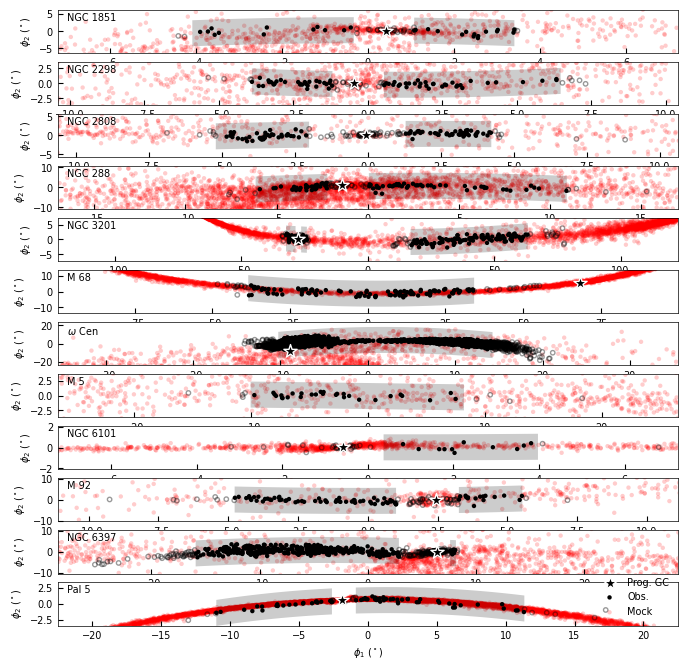

In [275]:
# longer integration

G_limit = 19
t_tot = 8000 * u.Myr
dt = 1 * u.Myr
n_steps = int(t_tot/dt)

center_on_poly = False

Tfrac = 0.05
N = 4000

f_rtid = 1
f_width = 6

n_obs_list = []
rate_list = []
mgc_list = []
ratio_list = []
T_list = []

# for age plot
length_list = []
width_list = []
ranges_list = []
x_age_list = []
y16_age_list = []
y84_age_list = []

class GreatCircle(coord.BaseCoordinateFrame):
    default_representation = coord.SphericalRepresentation
    default_differential = coord.SphericalCosLatDifferential

    frame_specific_representation_info = {
        coord.SphericalRepresentation: [
            coord.RepresentationMapping('lon', 'phi1'),
            coord.RepresentationMapping('lat', 'phi2'),
            coord.RepresentationMapping('distance', 'distance'),
        ]
    }

fig, axs = plt.subplots(len(gc_stream_ids), 1, figsize=(8,16), sharex=False, sharey=False)

for i in range(len(gc_stream_ids)):
    ax = axs[i]
    c = c_list[i]
    
    ax.text(0.015, 0.94, display_name_convert(gc_stream_list[i]), 
        va='top', ha='left', transform=ax.transAxes)
    
    c_gc = c.transform_to(coord.Galactocentric()).cartesian
    gc_w0 = gd.PhaseSpacePosition(c_gc)
    gc_mass = 10**mass_mw[np.where(name_mass_mw == gc_stream_list[i])[0][0]] * u.Msun
    print('%s %s GC mass = %.2e Msun, Rperi = %.2f kpc, Rapo = %.2f kpc'%(
        gc_stream_list[i], display_name_convert(gc_stream_list[i]), 
        gc_mass.value, data_mw['RPERI'][idx_with_stream][i], data_mw['RAPO'][idx_with_stream][i]))
    gc_pot = gp.PlummerPotential(m=gc_mass, b=4*u.pc, units=galactic)

    df = ms.ChenStreamDF(random_state=np.random.RandomState(0))
    gen = ms.MockStreamGenerator(df, pot, progenitor_potential=gc_pot)
    # stream, _ = gen.run(gc_w0, gc_mass, dt=-dt, n_steps=n_steps)
    
    orbit = pot.integrate_orbit(gc_w0, dt=-dt, n_steps=n_steps)
    
    pos = orbit.pos.xyz.value.T
    vel = orbit.vel.d_xyz.to('km/s').value.T

    r = np.sqrt(pos[:,0]**2 + pos[:,1]**2 + pos[:,2]**2)
    print('integrated orbit: Rperi = %.2f kpc, Rapo = %.2f kpc'%(np.min(r), np.max(r)))
    
    apos, peris = get_peri_apo(pos[:,0], pos[:,1], pos[:,2])
    T = np.mean(peris[1:] - peris[:-1])
    T_list.append(T*dt.value)
    Tsig = Tfrac * T
    rate = np.zeros(n_steps+1)
    for peri in peris:
        t_to_peri2 = (np.arange(n_steps+1) - peri)**2
        rate += 0.398942/Tsig*np.exp(-0.5*t_to_peri2/Tsig**2)/len(peris)
    
    rate = np.round(rate*N/np.sum(rate)).astype(int)
    
    stream, _ = gen.run(gc_w0, gc_mass, dt=-dt, n_steps=n_steps, n_particles=rate[::-1])
    stream_c = stream.to_coord_frame(coord.ICRS())

    @frame_transform_graph.transform(coord.StaticMatrixTransform, coord.ICRS, GreatCircle)
    def icrs_to_GreatCircle():
        return mat_stream_list[i]
    
    @frame_transform_graph.transform(coord.StaticMatrixTransform, GreatCircle, coord.ICRS)
    def GreatCircle_to_icrs():
        return matrix_transpose(mat_stream_list[i])
    
    stream_GreatCircle = stream_c.transform_to(GreatCircle())
    c_GreatCircle = c.transform_to(GreatCircle())

    # plot the progenitor GC
    phi1_gc = c_GreatCircle.phi1.wrap_at(180*u.deg).value
    phi2_gc  = c_GreatCircle.phi2.value
    if center_on_poly:
        ax.scatter(phi1_gc, phi2_gc-fit_poly(phi1_gc), s=100, marker='*', fc='k', ec='w', lw=1, zorder=100, label='Prog. GC')
    else:
        ax.scatter(phi1_gc, phi2_gc, s=100, marker='*', fc='k', ec='w', lw=1, zorder=100, label='Prog. GC')

    idx_structure = np.where(data_structure_mw['Cluster'] == gc_stream_list[i])[0]
    assert len(idx_structure) == 1
    rtid = data_structure_mw['rt'][idx_structure[0]]
    angle_rtid = (rtid / c_GreatCircle.distance.to('pc').value)*180/np.pi
        
    mask = (d['stream_id'] == gc_stream_ids[i]) & (d['G']<=G_limit)
    stream_obs_c = coord.ICRS(ra=d['ra'][mask]*u.deg, dec=d['dec'][mask]*u.deg)
    stream_obs_GreatCircle = stream_obs_c.transform_to(GreatCircle())

    phi1_obs = stream_obs_GreatCircle.phi1.wrap_at(180*u.deg).value
    phi2_obs = stream_obs_GreatCircle.phi2.value

    p = np.polyfit(phi1_obs, phi2_obs, deg=2)
    x = np.arange(-100,100,1)
    fit_poly = np.poly1d(p)
    width = np.sqrt(np.mean((phi2_obs-fit_poly(phi1_obs))**2))
    
    mask_left = (phi1_obs<phi1_gc-f_rtid*angle_rtid) & (phi2_obs-fit_poly(phi1_obs)>-f_width*width) & (phi2_obs-fit_poly(phi1_obs)<f_width*width)
    mask_right = (phi1_obs>phi1_gc+f_rtid*angle_rtid) & (phi2_obs-fit_poly(phi1_obs)>-f_width*width) & (phi2_obs-fit_poly(phi1_obs)<f_width*width)
    mask_lr = np.zeros_like(mask_left, dtype=bool)

    ranges = []
    masks = []
    if len(phi1_obs[mask_left]) >= 10:
        r = np.percentile(phi1_obs[mask_left], [10,90])
        ranges.append(r)
        mask_lr |= (mask_left & (phi1_obs>r[0]) & (phi1_obs<r[1]))
        masks.append((mask_left & (phi1_obs>r[0]) & (phi1_obs<r[1])))
    if len(phi1_obs[mask_right]) >= 10:
        r = np.percentile(phi1_obs[mask_right], [10,90])
        ranges.append(r)
        mask_lr |= (mask_right & (phi1_obs>r[0]) & (phi1_obs<r[1]))
        masks.append((mask_right & (phi1_obs>r[0]) & (phi1_obs<r[1])))
    # special treatment with omega cen, its GC is off center
    if gc_stream_list[i] == 'NGC_5139':
        r = np.percentile(phi1_obs, [10,90])
        ranges = [r]
        mask_lr = (phi2_obs-fit_poly(phi1_obs)>-f_width*width) & (phi2_obs-fit_poly(phi1_obs)<f_width*width) &  (phi1_obs>r[0]) & (phi1_obs<r[1])
        masks = [mask_lr]
    # special treatment with 3201, it has 3 segments
    if gc_stream_list[i] == 'NGC_3201':
        r = np.percentile(phi1_obs[mask_left], [10,90])
        ranges = [r]
        mask_right1 = mask_right & (phi1_obs<0)
        r = np.percentile(phi1_obs[mask_right1], [10,90])
        ranges.append(r)
        mask_right2 = mask_right & (phi1_obs>0)
        r = np.percentile(phi1_obs[mask_right2], [10,90])
        ranges.append(r)
        masks = [(mask_left & (phi1_obs>ranges[0][0]) & (phi1_obs<ranges[0][1])), 
            (mask_right1 & (phi1_obs>ranges[1][0]) & (phi1_obs<ranges[1][1])),
            (mask_right2 & (phi1_obs>ranges[2][0]) & (phi1_obs<ranges[2][1]))]
        mask_lr = ((mask_left & (phi1_obs>ranges[0][0]) & (phi1_obs<ranges[0][1])) | 
            (mask_right1 & (phi1_obs>ranges[1][0]) & (phi1_obs<ranges[1][1])) |
            (mask_right2 & (phi1_obs>ranges[2][0]) & (phi1_obs<ranges[2][1])))

    # if not center_on_poly:
    #     ax.plot(x, fit_poly(x), c='k', lw=2, alpha=0.6)

    # plot the obs. stars
    length = np.sqrt(np.mean(phi1_obs**2))
    if center_on_poly:
        ax.scatter(phi1_obs[~mask_lr], phi2_obs[~mask_lr]-fit_poly(phi1_obs[~mask_lr]), s=10, alpha=0.4, ec='k', fc='none', lw=1)
        ax.scatter(phi1_obs[mask_lr], phi2_obs[mask_lr]-fit_poly(phi1_obs[mask_lr]), s=10, alpha=1, ec='none', fc='k', label='Obs.')
        # ax.fill_between([-2*length, 2*length], [f_width*width, f_width*width], [-f_width*width, -f_width*width], ec='none', fc='k', alpha=0.2)
        for range in ranges:
            ax.fill_between(range, [f_width*width, f_width*width], [-f_width*width, -f_width*width], ec='none', fc='k', alpha=0.2)
    else:
        ax.scatter(phi1_obs[~mask_lr], phi2_obs[~mask_lr], s=10, alpha=0.4, ec='k', fc='none', lw=1)
        ax.scatter(phi1_obs[mask_lr], phi2_obs[mask_lr], s=10, alpha=1, ec='none', fc='k', label='Obs.')
        x = np.linspace(-2*length, 2*length,100)
        # ax.fill_between(x, fit_poly(x)+f_width*width, fit_poly(x)-f_width*width, ec='none', fc='k', alpha=0.2)
        for r in ranges:
            x = np.linspace(r[0], r[1],100)
            ax.fill_between(x, fit_poly(x)+f_width*width, fit_poly(x)-f_width*width, ec='none', fc='k', alpha=0.2)

    phi1_spray = stream_GreatCircle.phi1.wrap_at(180*u.deg).value
    phi2_spray = stream_GreatCircle.phi2.value
    # plot the mock stars
    if center_on_poly:
        ax.scatter(phi1_spray, phi2_spray-fit_poly(phi1_spray), s=10, alpha=0.2, fc='r', ec='none', label='Mock', zorder=0)
    else:
        ax.scatter(phi1_spray, phi2_spray, s=10, alpha=0.2, fc='r', ec='none', label='Mock', zorder=0)
    
    # compute the density for simulated streams
    num_in_range = 0
    length_in_range = 0
    density_spray_ranges = []
    for r in ranges:
        d_phi2 = phi2_spray-fit_poly(phi1_spray)
        width_spray = np.sqrt(np.mean((phi2_spray-fit_poly(phi1_spray))**2))
        weight = np.exp(-0.5*(d_phi2/width)**2) / np.exp(-0.5*(d_phi2/width_spray)**2)
        mask_in_range = (
            (phi1_spray>r[0]) & 
            (phi1_spray<=r[1]) & 
            (d_phi2>-f_width*width) & 
            (d_phi2<f_width*width)
        )
        # num_in_range += len(phi1_spray[mask_in_range])
        num_in_range += np.sum(weight[mask_in_range])
        length_in_range += r[1] - r[0]
        density_spray_ranges.append(np.sum(weight[mask_in_range])/(r[1]-r[0]))
    density_spray_ranges = np.array(density_spray_ranges)
    density_spray = num_in_range / length_in_range

    # directly get Gabs from Ibata distance
    # dist = d['d'][mask]
    # G_abs_here = G_abs[mask]
    
    # interp Gabs from fitted track. Needed for Ibata+24
    dist = np.full_like(d['G'][mask], fill_value=data_mw['Rsun'][idx_with_stream][i])
    G_abs_here = d['G'][mask] - 5*(np.log10(dist)+2)
    print('width in pc =', 1e3*data_mw['Rsun'][idx_with_stream][i]*width*np.pi/180)

    # compute the density of obs stream between phi1_l and phi1_h
    comp = np.inf
    idx = np.nan
    for j in range(len(old_iso)):
        iso = old_iso[j]
        mask1 = iso['label'] <= 3
        color = iso['G_BPmag'][mask1][::-1]-iso['G_RPmag'][mask1][::-1]
        Gmag = iso['Gmag'][mask1][::-1]
    
        dcolor = d['BP-RP'][mask] - np.interp(G_abs_here, Gmag, color)
        dcolor = np.mean(dcolor**2)
        if dcolor < comp:
            comp = dcolor
            idx = j
    iso = old_iso[idx]
    mask1 = iso['label'] <= 3
    color = iso['G_BPmag'][mask1][::-1]-iso['G_RPmag'][mask1][::-1]
    Gmag = iso['Gmag'][mask1][::-1]
    Mini = iso['Mini'][mask1][::-1]
    masses = np.interp(G_abs_here, Gmag, Mini)

    mass_limit = np.interp(G_limit - 5*(np.log10(dist)+2), Gmag, Mini)
    weight = kroupa(0, np.max(Mini)) / kroupa(mass_limit, np.max(Mini))

    mass_obs = np.sum(masses[mask_lr] * weight[mask_lr])
    density_obs_ranges = []
    for mask_seg, r in zip(masks,ranges):
        density_obs_ranges.append(np.sum(masses[mask_seg] * weight[mask_seg])/(r[1]-r[0]))
    density_obs = mass_obs / length_in_range
    density_obs_ranges = np.array(density_obs_ranges)
    n_obs_list.append(len(masses[mask_lr]))

    print('mass loss rates =', density_obs_ranges/density_spray_ranges*N/t_tot.value)
    print('mass loss rate = %.3f Msun/Myr'%(density_obs/density_spray*N/t_tot.value))
    print('mass loss rate / mass = %.3e 1/Myr'%(density_obs/density_spray*N/t_tot.value/gc_mass.value))
    rate_list.append(density_obs/density_spray*N/t_tot.value)
    mgc_list.append(gc_mass.value)

    idx_structure = np.where(data_structure_mw['Cluster'] == gc_stream_list[i])[0]
    assert len(idx_structure) == 1
    ratio = data_structure_mw['rh,m'][idx_structure[0]] / data_structure_mw['rt'][idx_structure[0]]
    print('rh / rt = %.3f'%ratio)
    ratio_list.append(ratio)

    ax.set_ylabel(r'$\phi_2\ (^\circ)$')
    # ax.set_xlim(-20,20)
    # ax.set_ylim(-5,5)
    # if i == 0:
    #     ax.set_xlim(-100,20)
    #     ax.set_ylim(-20,20)
    # if i == 1:
    #     ax.set_xlim(-20,180)
    #     ax.set_ylim(-20,20)
    # if gc_stream_list[i] == 'NGC_5139':
    #     ax.set_xlim(-10,40)
    #     ax.set_ylim(-10,40)

    ax.set_xlim(-3.5*length,3.5*length)
    # if not center_on_poly:
    #     width = np.sqrt(np.mean(phi2_obs**2))
    ax.set_ylim(-10*width,10*width)
    # ax.legend(loc='upper left', frameon=False)
    print('')

    # collect data for age plot
    length_list.append(length)
    width_list.append(width)
    ranges_list.append(ranges)
    
    bins = np.linspace(np.min(ranges)-length,np.max(ranges)+length, 16+1)
    x_age = (bins[1:] + bins[:-1])/2
    mask_in_width = (phi2_spray-fit_poly(phi1_spray)>-f_width*width) & (phi2_spray-fit_poly(phi1_spray)<f_width*width)
    y16_age = binned_statistic(phi1_spray[mask_in_width], -stream.release_time[mask_in_width]/1e3, statistic=f16, bins=bins)[0]
    y84_age = binned_statistic(phi1_spray[mask_in_width], -stream.release_time[mask_in_width]/1e3, statistic=f84, bins=bins)[0]
    x_age_list.append(x_age)
    y16_age_list.append(y16_age)
    y84_age_list.append(y84_age)

ax.set_xlabel(r'$\phi_1\ (^\circ)$')
ax.legend(loc='lower right', frameon=False)
# plt.gca().set_aspect(1)
plt.show()

rate_long_list = np.array(rate_list)
mgc_long_list = np.array(mgc_list)
ratio_long_list = np.array(ratio_list)
T_long_list = np.array(T_list)
n_obs_long_list = np.array(n_obs_list)

# for age plot
length_long_list = np.array(length_list)
width_long_list = np.array(width_list)
x_age_long_list = np.array(x_age_list)
y16_age_long_list = np.array(y16_age_list)
y84_age_long_list = np.array(y84_age_list)

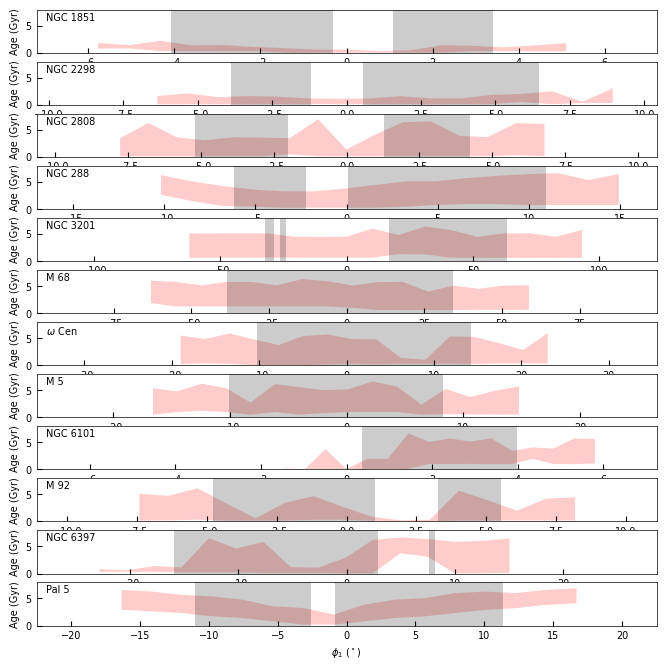

In [265]:

y_lim = 8 # Gyr

fig, axs = plt.subplots(len(gc_stream_ids), 1, figsize=(8,8), sharex=False, sharey=False)

for i in range(len(gc_stream_ids)):
    ax = axs[i]
    
    ax.text(0.015, 0.94, display_name_convert(gc_stream_list[i]), 
        va='top', ha='left', transform=ax.transAxes)
    
    ranges = ranges_list[i]
    x = x_age_long_list[i]
    y16 = y16_age_long_list[i]
    y84 = y84_age_long_list[i]
    length = length_long_list[i]
    
    # plt.scatter(phi1_spray, -stream.release_time)
    ax.fill_between(x, y16, y84, fc='r', ec='none', alpha=0.2)
    for r in ranges:
        ax.fill_between([r[0], r[1]], [0,0], [y_lim, y_lim], fc='k', ec='none', alpha=0.2)
    
    ax.set_ylim(0, y_lim)
    ax.set_ylabel(r'Age (Gyr)')
    
    ax.set_xlim(-3.5*length,3.5*length)

ax.set_xlabel(r'$\phi_1\ (^\circ)$')
plt.show()

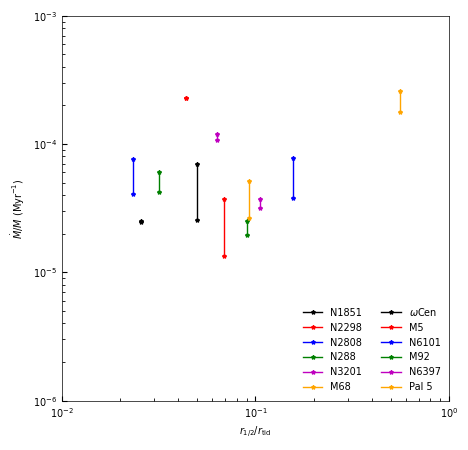

In [292]:

fig, axs = plt.subplots(1, 1, figsize=(5,5), sharex=False, sharey=False)

for i in range(len(gc_stream_ids)):
    # if i == 1:
    #     continue
    # plt.scatter(ratio_list[i], rate_list[i]/mgc_list[i], c=cs[i], s=10, marker='*', label=display_name_convert(gc_stream_list[i]))
    # err_rel = 1 / np.sqrt(n_obs_list[i])
    # plt.plot([ratio_list[i],ratio_list[i]], [(1-err_rel)*rate_list[i]/mgc_list[i],(1+err_rel)*rate_list[i]/mgc_list[i]], c=cs[i])

    plt.plot([ratio_list[i], ratio_list[i]], [rate_short_list[i]/mgc_list[i],rate_long_list[i]/mgc_list[i]], 
        c=cs[i], ms=3, marker='*', label=display_name_simple_convert(gc_stream_list[i]))

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$r_{1/2}/r_{\rm tid}$')
plt.ylabel(r'$\dot{M}/M\ ({\rm Myr^{-1}})$')
plt.xlim(1e-2,1e0)
plt.ylim(1e-6,1e-3)

plt.legend(loc='lower right', frameon=False, ncol=2)
plt.show()

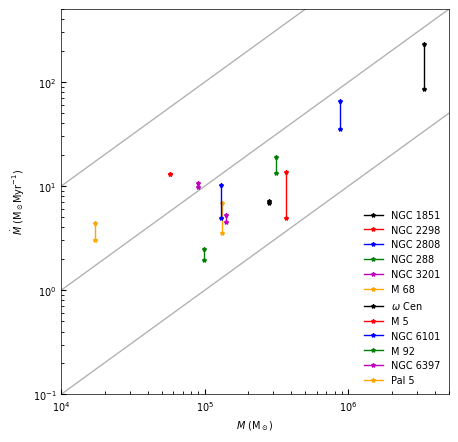

In [278]:

fig, axs = plt.subplots(1, 1, figsize=(5,5), sharex=False, sharey=False)

x = np.logspace(4,7,10+1)
# plt.plot(x, 30 * (x/2e5)**(1/3), c='k', ls='--', label=r'$(M/2e5)^{1/3}\times 30\,{\rm M_\odot Myr^{-1}}\ (R_{\rm eff}\sim 1~{\rm kpc})$')
# plt.plot(x, 3 * (x/2e5)**(1/3), c='k', label=r'$(M/2e5)^{1/3}\times 3\,{\rm M_\odot Myr^{-1}}\ (R_{\rm eff}\sim 10~{\rm kpc})$')

for i in range(len(gc_stream_ids)):
    # if i == 1:
    #     continue
    # plt.scatter(mgc_list[i], rate_list[i], c=cs[i], s=100, marker='*', label=gc_stream_list[i])
    plt.plot([mgc_list[i],mgc_list[i]], [rate_short_list[i],rate_long_list[i]], 
        c=cs[i], ms=3, marker='*', label=display_name_convert(gc_stream_list[i]))

plt.plot(x, x/1e3, c='k', alpha=0.3)
plt.plot(x, x/1e4, c='k', alpha=0.3)
plt.plot(x, x/1e5, c='k', alpha=0.3)

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$M\ ({\rm M_\odot})$')
plt.ylabel(r'$\dot{M}\ ({\rm M_\odot Myr^{-1}})$')
plt.xlim(1e4,5e6)
plt.ylim(1e-1,5e2)

plt.legend(loc='lower right', frameon=False)
plt.show()

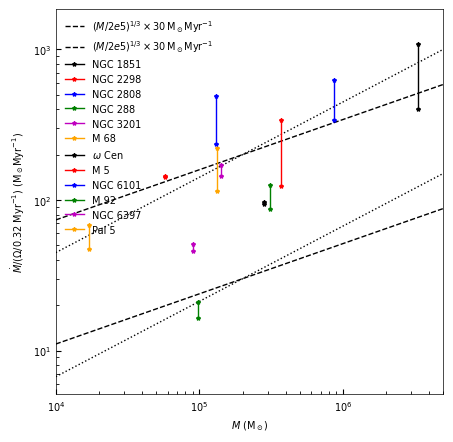

In [282]:

fig, axs = plt.subplots(1, 1, figsize=(5,5), sharex=False, sharey=False)

x = np.logspace(4,7,10+1)
plt.plot(x, 30 * (x/2e5)**(1/3), c='k', ls='--', label=r'$(M/2e5)^{1/3}\times 30\,{\rm M_\odot Myr^{-1}}$')
plt.plot(x, 30 * (x/2e5)**(1/2), c='k', ls=':')

plt.plot(x, 200 * (x/2e5)**(1/3), c='k', ls='--', label=r'$(M/2e5)^{1/3}\times 30\,{\rm M_\odot Myr^{-1}}$')
plt.plot(x, 200 * (x/2e5)**(1/2), c='k', ls=':')

for i in range(len(gc_stream_ids)):
    # if i == 1:
    #     continue
    idx_structure = np.where(data_structure_mw['Cluster'] == gc_stream_list[i])[0]
    assert len(idx_structure) == 1
    rh = data_structure_mw['rh,m'][idx_structure[0]]
    # plt.scatter(mgc_list[i], rate_list[i]/(2*np.pi/T_list[i]/0.32)/(rh/5)**(2/2), c=cs[i], s=100, marker='*', label=gc_stream_list[i])
    plt.plot([mgc_list[i],mgc_list[i]], np.array([rate_short_list[i],rate_long_list[i]])/(2*np.pi/T_list[i]/0.32), #/(rh/5)**(2/2), 
        c=cs[i], ms=3, marker='*', label=display_name_convert(gc_stream_list[i]))

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$M\ ({\rm M_\odot})$')
plt.ylabel(r'$\dot{M}/(\Omega/0.32\ {\rm Myr^{-1}})\ ({\rm M_\odot Myr^{-1}})$')
plt.xlim(1e4,5e6)
# plt.ylim(1e1,2e2)

plt.legend(loc='upper left', frameon=False)
plt.show()

In [ ]:
def powerlaw_imf(a, m):
    return m**a

def integrate_powerlaw_imf(a, mmin, mmax):
    if a != -1:
        # int_mmin^mmax m^a dm = [mmax^(a+1) - mmin^(a+1)]/(a+1)
        return (mmax**(a+1) - mmin**(a+1))/(a+1)
    else:
        return np.log(mmax) - np.log(mmin)


def resample_powerlaw_imf(a, mmin, mmax, M, rng):
    m_mean = integrate_powerlaw_imf(a+1, mmin, mmax) / integrate_powerlaw_imf(a, mmin, mmax)
    N = int(M / m_mean)
    
    x = rng.uniform(size=N)
    if a != -1:
        return ((mmax**(a+1) - mmin**(a+1)) * x +mmin**(a+1))**(1/(a+1))
    else:
        return np.exp(x*(np.log(mmax)-np.log(mmin))+np.log(mmin))

In [ ]:
G_limit = 18
t_tot = 2000 * u.Myr
dt = 1 * u.Myr
n_steps = int(t_tot/dt)

Tfrac = 0.05
N = 1000

rate_list = []
mgc_list = []
ratio_list = []
T_list = []

class GreatCircle(coord.BaseCoordinateFrame):
    default_representation = coord.SphericalRepresentation
    default_differential = coord.SphericalCosLatDifferential

    frame_specific_representation_info = {
        coord.SphericalRepresentation: [
            coord.RepresentationMapping('lon', 'phi1'),
            coord.RepresentationMapping('lat', 'phi2'),
            coord.RepresentationMapping('distance', 'distance'),
        ]
    }

fig, axs = plt.subplots(len(gc_stream_ids), 1, figsize=(12,12), sharex=False, sharey=False)

for i in [5]:
    ax = axs[i]
    
    c = coord.ICRS(ra=data_mw['RA'][idx_with_stream][i] * u.deg, dec=data_mw['DEC'][idx_with_stream][i] * u.deg,
        distance=data_mw['Rsun'][idx_with_stream][i] * u.kpc,
        pm_ra_cosdec=data_mw['mu_alpha'][idx_with_stream][i] * u.mas/u.yr,
        pm_dec=data_mw['mu_delta'][idx_with_stream][i] * u.mas/u.yr,
        radial_velocity=data_mw['<RV>'][idx_with_stream][i] * u.km/u.s)
    
    c_gc = c.transform_to(coord.Galactocentric()).cartesian
    gc_w0 = gd.PhaseSpacePosition(c_gc)
    gc_mass = 10**mass_mw[np.where(name_mass_mw == gc_stream_list[i])[0][0]] * u.Msun
    print('%s GC mass = %.2e Msun, Rperi = %.2f kpc, Rapo = %.2f kpc'%(
        gc_stream_list[i], gc_mass.value, data_mw['RPERI'][idx_with_stream][i], data_mw['RAPO'][idx_with_stream][i]))
    gc_pot = gp.PlummerPotential(m=gc_mass, b=4*u.pc, units=galactic)

    df = ms.ChenStreamDF()
    gen = ms.MockStreamGenerator(df, pot, progenitor_potential=gc_pot)
    # stream, _ = gen.run(gc_w0, gc_mass, dt=-dt, n_steps=n_steps)
    
    orbit = pot.integrate_orbit(gc_w0, dt=-dt, n_steps=n_steps)
    
    pos = orbit.pos.xyz.value.T
    vel = orbit.vel.d_xyz.to('km/s').value.T

    r = np.sqrt(pos[:,0]**2 + pos[:,1]**2 + pos[:,2]**2)
    print('integrated orbit: Rperi = %.2f kpc, Rapo = %.2f kpc'%(np.min(r), np.max(r)))
    
    apos, peris = get_peri_apo(pos[:,0], pos[:,1], pos[:,2])
    T = np.mean(peris[1:] - peris[:-1])
    T_list.append(T*dt.value)
    Tsig = Tfrac * T
    rate = np.zeros(n_steps+1)
    for peri in peris:
        t_to_peri2 = (np.arange(n_steps+1) - peri)**2
        rate += 0.398942/Tsig*np.exp(-0.5*t_to_peri2/Tsig**2)/len(peris)
    
    rate = np.round(rate*N/np.sum(rate)).astype(int)
    
    stream, _ = gen.run(gc_w0, gc_mass, dt=-dt, n_steps=n_steps, n_particles=rate[::-1])




    stream_c = stream.to_coord_frame(coord.ICRS())

    # rotate to great circle frame

    # step 1: rotate the GC to center
    GreatCircle_MATRIX = rotation_matrix(ra_wrap_at_180[idx_with_stream][i]*u.deg, 'z')
    GreatCircle_MATRIX = rotation_matrix(-data_mw['DEC'][idx_with_stream][i]*u.deg, 'y') @ GreatCircle_MATRIX
    
    @frame_transform_graph.transform(coord.StaticMatrixTransform, coord.ICRS, GreatCircle)
    def icrs_to_GreatCircle():
        return GreatCircle_MATRIX
    
    @frame_transform_graph.transform(coord.StaticMatrixTransform, GreatCircle, coord.ICRS)
    def GreatCircle_to_icrs():
        return matrix_transpose(GreatCircle_MATRIX)
    
    # step 2: align the frame
    # method 1: align the GC's velocity
    # c_GreatCircle = c.transform_to(GreatCircle())
    # rotate = np.arctan2(c_GreatCircle.pm_phi2, c_GreatCircle.pm_phi1_cosphi2).to('deg').value
    # GreatCircle_MATRIX = rotation_matrix(rotate*u.deg, 'x') @ GreatCircle_MATRIX
    
    # method 2: align the stream stars
    mask = (d['stream_id'] == gc_stream_ids[i]) & (d['G']<=G_limit)
    stream_obs_c = coord.ICRS(ra=d['ra'][mask]*u.deg, dec=d['dec'][mask]*u.deg)
    stream_obs_GreatCircle = stream_obs_c.transform_to(GreatCircle())
    rad = np.sqrt(stream_obs_GreatCircle.phi1.wrap_at(180*u.deg).value**2+stream_obs_GreatCircle.phi2.value**2)
    z = np.polyfit(stream_obs_GreatCircle.phi1.wrap_at(180*u.deg).value[rad<50], stream_obs_GreatCircle.phi2.value[rad<50], deg=1)
    if gc_stream_list[i] == 'NGC_5139':
        z = np.polyfit(stream_obs_GreatCircle.phi1.wrap_at(180*u.deg).value[rad<50], stream_obs_GreatCircle.phi2.value[rad<50], deg=1)
    rotate = np.arctan(z[0])
    GreatCircle_MATRIX = rotation_matrix(rotate*u.rad, 'x') @ GreatCircle_MATRIX
    
    @frame_transform_graph.transform(coord.StaticMatrixTransform, coord.ICRS, GreatCircle)
    def icrs_to_GreatCircle():
        return GreatCircle_MATRIX
    
    @frame_transform_graph.transform(coord.StaticMatrixTransform, GreatCircle, coord.ICRS)
    def GreatCircle_to_icrs():
        return matrix_transpose(GreatCircle_MATRIX)
    
    stream_GreatCircle = stream_c.transform_to(GreatCircle())
    c_GreatCircle = c.transform_to(GreatCircle())
    
    stream_obs_GreatCircle = stream_obs_c.transform_to(GreatCircle())

    phi1_obs = stream_obs_GreatCircle.phi1.wrap_at(180*u.deg).value
    phi2_obs = stream_obs_GreatCircle.phi2.value
    ax.scatter(phi1_obs, phi2_obs, s=10, alpha=1, fc=cs[i])

    # compute the density between phi1_l and phi1_h
    if i == 0:
        phi1_l, phi1_h = np.percentile(phi1_obs[phi1_obs<0], [10,90])
    elif i == 1:
        phi1_l, phi1_h = np.percentile(phi1_obs[phi1_obs>0], [10,90])
    else:
        phi1_l, phi1_h = np.percentile(phi1_obs[phi1_obs>0], [10,90])
    ax.vlines([phi1_l, phi1_h], -20, 20, color='k', alpha=0.5)

    comp = np.inf
    idx = np.nan
    
    for j in range(len(old_iso)):
        iso = old_iso[j]
        mask1 = iso['label'] <= 3
        color = iso['G_BPmag'][mask1][::-1]-iso['G_RPmag'][mask1][::-1]
        Gmag = iso['Gmag'][mask1][::-1]
    
        dcolor = d['BP-RP'][mask] - np.interp(G_abs[mask], Gmag, color)
        dcolor = np.mean(dcolor**2)
        if dcolor < comp:
            comp = dcolor
            idx = j
        
    iso = old_iso[idx]
    mask1 = iso['label'] <= 3
    color = iso['G_BPmag'][mask1][::-1]-iso['G_RPmag'][mask1][::-1]
    Gmag = iso['Gmag'][mask1][::-1]
    Mini = iso['Mini'][mask1][::-1]
    masses = np.interp(G_abs[mask], Gmag, Mini)

    mass_limit = np.interp(G_limit - 5*(np.log10(d['d'][mask])+2), Gmag, Mini)
    weight = kroupa(0, np.max(Mini)) / kroupa(mass_limit, np.max(Mini))
    a = -1.5
    weight = integrate_powerlaw_imf(a+1, 0, np.max(Mini)) / integrate_powerlaw_imf(a+1, mass_limit, np.max(Mini))

    mask_arm = (phi1_obs>phi1_l) & (phi1_obs<=phi1_h)
    mass_obs = np.sum(masses[mask_arm] * weight[mask_arm])
    density_obs = mass_obs / (phi1_h - phi1_l)

    phi1_spray = stream_GreatCircle.phi1.wrap_at(180*u.deg).value
    phi2_spray = stream_GreatCircle.phi2.value
    ax.scatter(phi1_spray, phi2_spray, s=10, alpha=0.1, fc=cs[i])
    ax.scatter(c_GreatCircle.phi1.wrap_at(180*u.deg),c_GreatCircle.phi2, s=400, marker='*', fc=cs[i], ec='w', lw=2, label=gc_stream_list[i])

    # compute the density between phi1_l and phi1_h for simulated streams
    phi2_l = -5
    phi2_h = 5
    if i == 1 or i == 0:
        phi2_l = -20
        phi2_h = 20
    if gc_stream_list[i] == 'NGC_5139':
        phi2_l = 0
        phi2_h = 40
    density_spray = len(phi1_spray[(phi1_spray>phi1_l) & (phi1_spray<=phi1_h) & (phi2_spray>phi2_l) & (phi2_spray<=phi2_h)]) / (phi1_h - phi1_l)

    print('mass loss rate = %.3f Msun/Myr'%(density_obs/density_spray*N/t_tot.value))
    print('mass loss rate / mass = %.3e 1/Myr'%(density_obs/density_spray*N/t_tot.value/gc_mass.value))
    rate_list.append(density_obs/density_spray*N/t_tot.value)
    mgc_list.append(gc_mass.value)

    idx_structure = np.where(data_structure_mw['Cluster'] == gc_stream_list[i])[0]
    assert len(idx_structure) == 1
    ratio = data_structure_mw['rh,m'][idx_structure[0]] / data_structure_mw['rt'][idx_structure[0]]
    print('rh / rt = %.3f'%ratio)
    ratio_list.append(ratio)

    # resampling
    rng = np.random.default_rng(i)
    mass_obs_resample_list = []
    N_obs_resample_list = []
    for repeat in range(1000):
        m_limit = 0.5
        mass_obs_above_limit = mass_obs * integrate_powerlaw_imf(a+1, m_limit, np.max(Mini)) / integrate_powerlaw_imf(a+1, 0, np.max(Mini))
        m = resample_powerlaw_imf(a, m_limit, np.max(Mini), mass_obs_above_limit, rng)
        G_abs_resample = np.interp(m, Mini[::-1], Gmag[::-1])
    
        # assume resamples have the same radius
        d_array = np.full_like(m, fill_value=np.mean(d['d'][mask]))
        G_mag_resample = G_abs_resample + 5*(np.log10(d_array)+2)
        mass_limit = np.interp(G_limit - 5*(np.log10(d_array)+2), Gmag, Mini)
        weight = integrate_powerlaw_imf(a+1, 0, np.max(Mini)) / integrate_powerlaw_imf(a+1, mass_limit, np.max(Mini))
        mass_obs_resample = np.sum(m[G_mag_resample<=G_limit] * weight[G_mag_resample<=G_limit])
        # print(mass_obs, mass_obs_resample)
        mass_obs_resample_list.append(mass_obs_resample)
        N_obs_resample_list.append(len(m[G_mag_resample<=G_limit]))
    
    ax.set_xlabel(r'$\phi_1\ (^\circ)$')
    ax.set_ylabel(r'$\phi_2\ (^\circ)$')
    ax.set_xlim(-20,20)
    ax.set_ylim(-5,5)
    if i == 0:
        ax.set_xlim(-100,20)
        ax.set_ylim(-20,20)
    if i == 1:
        ax.set_xlim(-20,180)
        ax.set_ylim(-20,20)
    if gc_stream_list[i] == 'NGC_5139':
        ax.set_xlim(-10,40)
        ax.set_ylim(-10,40)
        
    ax.legend(loc='upper left', frameon=False)
    print('')
# plt.gca().set_aspect(1)
plt.show()

rate_list = np.array(rate_list)
mgc_list = np.array(mgc_list)
ratio_list = np.array(ratio_list)
T_list = np.array(T_list)

In [ ]:
from scipy.special import gamma

bins = np.linspace(4000, 16000, 23)
plt.hist(mass_obs_resample_list, bins=bins, histtype='step', density=True)
# plt.hist(mass_obs_resample_list, bins=200, histtype='step', density=True)
# plt.vlines(mass_obs, 0, 25, color='r')

N_obs = len(masses[mask_arm])
m_mean = mass_obs / N_obs
n = np.arange(2*N_obs, dtype=int)
x = m_mean * n
pois = poisson(N_obs)
y_poisson = pois.pmf(n)/m_mean

plt.plot(x, y_poisson)

plt.xlim(np.min(mass_obs_resample_list), np.max(mass_obs_resample_list))